# Clustering and K-means

**Clustering** means putting data into groups so that things in the same group are similar to each other, and
different from things in other groups. Nobody tells the computer what the groups are, or even what they mean. It
only has the data. That makes clustering a kind of **unsupervised learning**.

Some examples:

- A shop groups its customers by how often they visit and how much they spend.
- A music app groups songs that sound alike.
- A photo editor groups similar colours together to shrink an image.

**K-means** is the most widely used clustering method. In this notebook we:

1. run k-means by hand on eight points, one step at a time
2. use scikit-learn on a larger set of customers
3. see why scaling the data matters
4. choose the number of clusters
5. use k-means to reduce the number of colours in a photo

There are exercises along the way. Write your code in the cells marked `# Your code here`.

Run each cell in order with Shift + Enter.

## 1. Setting up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

COLOURS = np.array(["#2a78d6", "#eb6834", "#1baf7a", "#8a5cc2"])
MARKERS = ["o", "s", "^", "D"]

---
## 2. K-means by hand

### The idea

K-means needs to be told **k**, the number of clusters you want. Each cluster has a **centre**, which is just the
average position of the points in it. The algorithm repeats two steps:

1. **Assign:** every point joins the cluster whose centre is nearest.
2. **Update:** every centre moves to the average (mean) of the points that joined it.

It keeps going until no point changes cluster. To get started, it needs some first guesses for the centres.

### The data

Here are eight points, labelled A to H. By eye there are two groups, but the computer only sees the numbers.

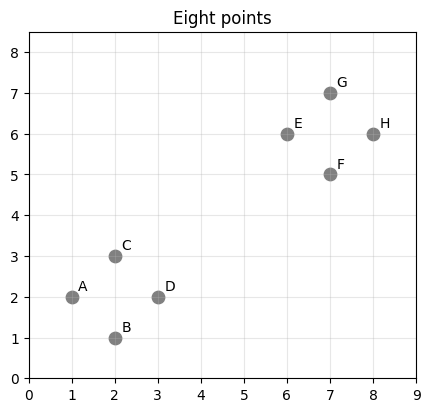

In [2]:
points = np.array([[1, 2], [2, 1], [2, 3], [3, 2],
                   [6, 6], [7, 5], [7, 7], [8, 6]])
names = list("ABCDEFGH")

plt.figure(figsize=(5, 4.5))
plt.scatter(points[:, 0], points[:, 1], color="grey", s=80)
for (x, y), n in zip(points, names):
    plt.annotate(n, (x + 0.15, y + 0.15))
plt.xlim(0, 9); plt.ylim(0, 8.5)
plt.grid(alpha=0.3)
plt.title("Eight points")
plt.show()

### Three small helper functions

- `distance` works out the straight-line distance between two points, using Pythagoras.
- `assign` gives each point the number of its nearest centre.
- `update` moves each centre to the mean of its points.

In [3]:
def distance(p, q):
    return np.sqrt((p[0] - q[0]) ** 2 + (p[1] - q[1]) ** 2)

def assign(points, centres):
    labels = []
    for p in points:
        distances = [distance(p, c) for c in centres]
        labels.append(int(np.argmin(distances)))     # index of the nearest centre
    return np.array(labels)

def update(points, labels, k):
    return np.array([points[labels == j].mean(axis=0) for j in range(k)])

def plot_clusters(points, labels, centres, title):
    plt.figure(figsize=(5, 4.5))
    for j in range(len(centres)):
        mask = labels == j
        plt.scatter(points[mask, 0], points[mask, 1], color=COLOURS[j], marker=MARKERS[j], s=80)
        plt.scatter(centres[j, 0], centres[j, 1], color=COLOURS[j], marker="X", s=300, edgecolor="black")
    for (x, y), n in zip(points, names):
        plt.annotate(n, (x + 0.15, y + 0.15))
    plt.xlim(0, 9); plt.ylim(0, 8.5)
    plt.grid(alpha=0.3)
    plt.title(title)
    plt.show()

### Running the algorithm one round at a time

We start the two centres on points B and D. This is a deliberately poor start, because both centres are in the
same group. Watch how they move.

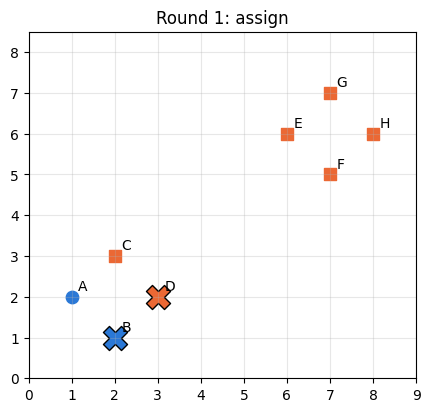

Round 1: centres move from [[2.0, 1.0], [3.0, 2.0]] to [[1.5, 1.5], [5.5, 4.83]]


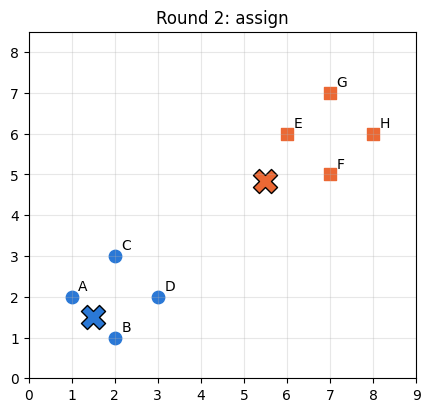

Round 2: centres move from [[1.5, 1.5], [5.5, 4.83]] to [[2.0, 2.0], [7.0, 6.0]]


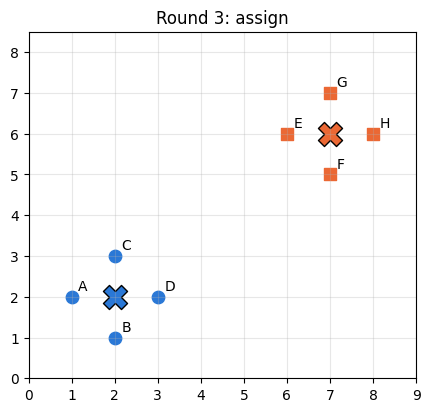

Round 3: centres move from [[2.0, 2.0], [7.0, 6.0]] to [[2.0, 2.0], [7.0, 6.0]]
The centres did not move, so k-means stops.


In [4]:
centres = np.array([[2.0, 1.0], [3.0, 2.0]])   # start on B and D

for round_number in range(1, 5):
    labels = assign(points, centres)
    plot_clusters(points, labels, centres, f"Round {round_number}: assign")
    new_centres = update(points, labels, k=2)
    print(f"Round {round_number}: centres move from {centres.round(2).tolist()} to {new_centres.round(2).tolist()}")
    if np.allclose(new_centres, centres):
        print("The centres did not move, so k-means stops.")
        break
    centres = new_centres

### What happened

- **Round 1:** blue only won A and B. Orange won the other six, including C, which by eye belongs with A and B.
  Orange's centre then moved to the mean of its six points, which pulled it a long way to the top right.
- **Round 2:** with orange far away, C and D are now nearer blue, so they switch. The centres move to (2, 2) and
  (7, 6), the middle of each group.
- **Round 3:** no point changes cluster, so the centres do not move and the algorithm stops.

The centres **follow their points**, and the points **choose the nearest centre**. Each round the clusters get a
little tighter until nothing changes.

### Exercise 1

Use the `distance` function to work out how far point **H (8, 6)** is from each of the two **starting** centres,
(2, 1) and (3, 2). Which centre is H nearer to in round 1?

In [5]:
# Your code here

### Exercise 2

The final orange cluster contains E, F, G and H. Use `np.mean` with `axis=0` to work out its centre, and check it
matches the (7, 6) found above. (Hint: E to H are `points[4:]`.)

In [6]:
# Your code here

---
## 3. The same thing with scikit-learn

In practice we let scikit-learn do the work. `n_init=10` means it runs k-means 10 times from different starting
centres and keeps the best result, because an unlucky start can leave k-means stuck with poor clusters.

In [7]:
km = KMeans(n_clusters=2, n_init=10, random_state=0)
km.fit(points)

print("Centres:")
print(km.cluster_centers_)
print("Cluster of each point:", dict(zip(names, km.labels_.tolist())))
print("Inertia:", km.inertia_)

Centres:
[[7. 6.]
 [2. 2.]]
Cluster of each point: {'A': 1, 'B': 1, 'C': 1, 'D': 1, 'E': 0, 'F': 0, 'G': 0, 'H': 0}
Inertia: 8.0


- `cluster_centers_` are the final centres: the same (2, 2) and (7, 6) we found by hand.
- `labels_` says which cluster each point is in. The numbers 0 and 1 are just names, and they may come out the other
  way round from our colours.
- `inertia_` is the total of the **squared distances** from each point to its centre. Smaller means tighter
  clusters. Here every point is exactly 1 away from its centre, so the total is 8.

### Exercise 3

Fit k-means to the same eight points with **k = 3** and print the centres and labels. Then use `plot_clusters` to
draw the result. What has k-means done with the extra cluster? Is it a sensible answer?

(Use `plot_clusters(points, km3.labels_, km3.cluster_centers_, "k = 3")`.)

In [8]:
# Your code here

---
## 4. A bigger example: grouping customers

A shop has 120 customers. For each one we know the number of **visits per month** and their **average monthly spend
in pounds**. The data is simulated for this notebook. The shop wants to find groups of similar customers so it can
treat each group differently.

In [9]:
rng = np.random.default_rng(1)
groups = [(3, 350, 2, 80), (14, 450, 2.5, 100), (8, 1300, 2, 180)]   # (visits, spend, spread, spread)
visits, spend = [], []
for mean_v, mean_s, sd_v, sd_s in groups:
    visits += list(np.clip(rng.normal(mean_v, sd_v, 40), 0, None).round())
    spend += list(rng.normal(mean_s, sd_s, 40).round())

customers = pd.DataFrame({"visits": visits, "spend": spend})
customers.describe().round(1)

,visits,spend
count,120.0,120.0
mean,8.3,675.1
std,4.9,432.7
min,0.0,203.0
25%,4.0,347.0
50%,8.0,425.0
75%,12.2,1168.0
max,18.0,1664.0


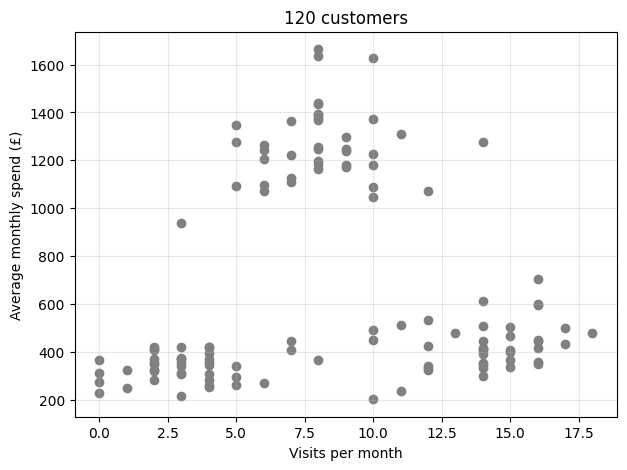

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(customers["visits"], customers["spend"], color="grey")
plt.xlabel("Visits per month")
plt.ylabel("Average monthly spend (£)")
plt.title("120 customers")
plt.grid(alpha=0.3)
plt.show()

Looking at the chart, you can probably see three groups. Let's see what k-means finds with k = 3.

### First attempt: without scaling

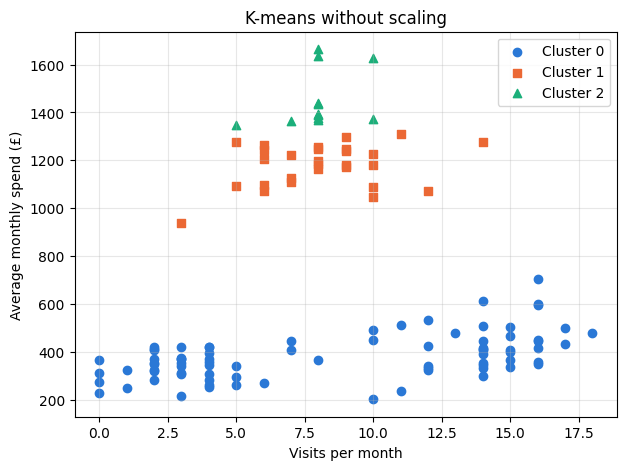

In [11]:
km_raw = KMeans(n_clusters=3, n_init=10, random_state=0)
customers["cluster_raw"] = km_raw.fit_predict(customers[["visits", "spend"]])

plt.figure(figsize=(7, 5))
for j in range(3):
    group = customers[customers["cluster_raw"] == j]
    plt.scatter(group["visits"], group["spend"], color=COLOURS[j], marker=MARKERS[j], label=f"Cluster {j}")
plt.xlabel("Visits per month")
plt.ylabel("Average monthly spend (£)")
plt.title("K-means without scaling")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

That does not look right. The two groups at the bottom have been merged, and the high spenders have been cut in
half.

The reason is the **units**. Spend goes from about £200 to £1,700, but visits only go from 0 to 18. K-means uses
distance, so a difference of £100 in spend counts as much as a difference of 100 visits. Spend completely
dominates, and visits are almost ignored, so k-means is really only clustering on spend.

### Second attempt: with scaling

`StandardScaler` rescales each feature so it has a mean of 0 and a standard deviation of 1. After scaling, both
features have a similar spread and count equally.

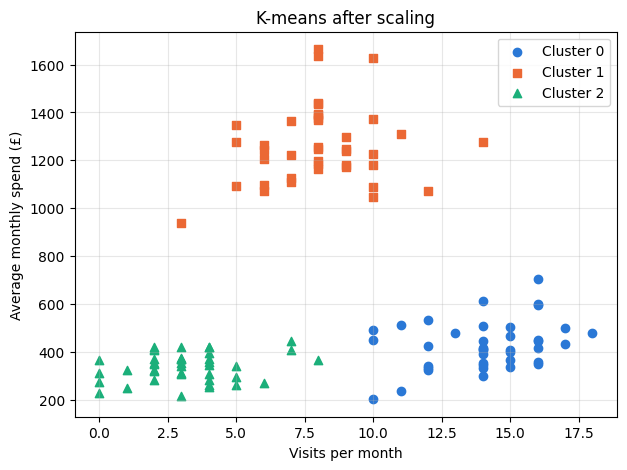

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customers[["visits", "spend"]])

km = KMeans(n_clusters=3, n_init=10, random_state=0)
customers["cluster"] = km.fit_predict(X_scaled)

plt.figure(figsize=(7, 5))
for j in range(3):
    group = customers[customers["cluster"] == j]
    plt.scatter(group["visits"], group["spend"], color=COLOURS[j], marker=MARKERS[j], label=f"Cluster {j}")
plt.xlabel("Visits per month")
plt.ylabel("Average monthly spend (£)")
plt.title("K-means after scaling")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Now the three groups match what we can see. **Always scale your features before k-means** when they are measured
in different units.

The chart is still drawn in the original units, so it is easy to read. Only the clustering used the scaled values.

### Exercise 4

Describe each cluster in words. Use `groupby` to find the average visits and spend in each cluster, and count how
many customers are in each one. Then give each cluster a short, sensible name that a marketing team would
understand.

(Hint: `customers.groupby("cluster")[["visits", "spend"]].mean()` and `customers["cluster"].value_counts()`.)

In [13]:
# Your code here

### Exercise 5

A new customer visits **12 times a month** and spends **£600**. Which cluster does k-means put them in?

Be careful: the model was trained on **scaled** data, so you must scale the new customer with the same `scaler`
before calling `km.predict`.

In [14]:
new_customer = pd.DataFrame([[12, 600]], columns=["visits", "spend"])

# Your code here

---
## 5. How many clusters?

In real data we usually cannot draw a chart and see the groups, so how do we choose k? One common method is the
**elbow method**: run k-means for several values of k and plot the inertia (the total squared distance to the
centres).

Inertia always goes down as k goes up, because more centres means every point is closer to one. But at some
point adding another cluster stops helping much. That bend in the line, the "elbow", is a good choice for k.

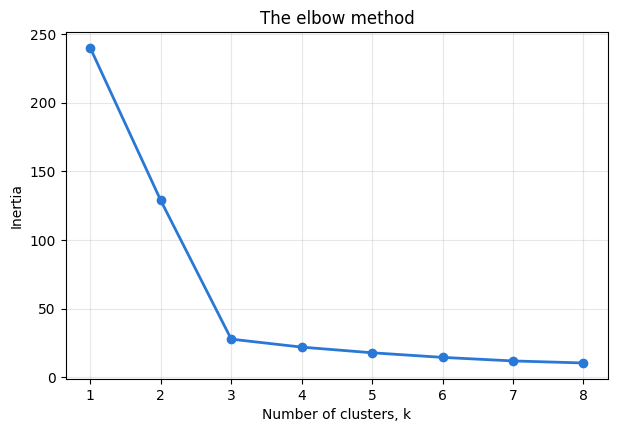

,k,inertia
0,1,240.0
1,2,128.8
2,3,27.8
3,4,22.0
4,5,17.9
5,6,14.5
6,7,11.9
7,8,10.4


In [15]:
k_values = range(1, 9)
inertias = []
for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 4.5))
plt.plot(k_values, inertias, marker="o", color=COLOURS[0], linewidth=2)
plt.xlabel("Number of clusters, k")
plt.ylabel("Inertia")
plt.title("The elbow method")
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({"k": list(k_values), "inertia": np.round(inertias, 1)})

### Exercise 6

Look at the elbow chart and the table above.

1. Where is the elbow? How much does the inertia drop going from k = 2 to k = 3, and from k = 3 to k = 4?
2. Why should you not just pick the k with the lowest inertia?

Write your answer in a markdown cell, or as comments below.

In [16]:
# Your answer here

---
## 6. K-means on a photo: reducing colours

Every pixel in a colour photo is three numbers: how much **red**, **green** and **blue** it has, each from 0 to 255.
So we can treat every pixel as a point with three features and cluster them. Each cluster centre is then an
average colour. If we repaint every pixel with its centre's colour, the photo uses only k colours.

This photo of the Summer Palace in Beijing comes with scikit-learn.

In [17]:
from sklearn.datasets import load_sample_image

image = load_sample_image("china.jpg")
pixels = image.reshape(-1, 3)       # one row per pixel, columns red, green, blue

print("Image size:", image.shape[0], "x", image.shape[1], "=", len(pixels), "pixels")
print("Different colours:", len(np.unique(pixels, axis=0)))

Image size: 427 x 640 = 273280 pixels


Different colours: 96615


To keep it quick, we fit k-means on a random sample of 10,000 pixels, then use `predict` to put **every** pixel
into its nearest cluster.

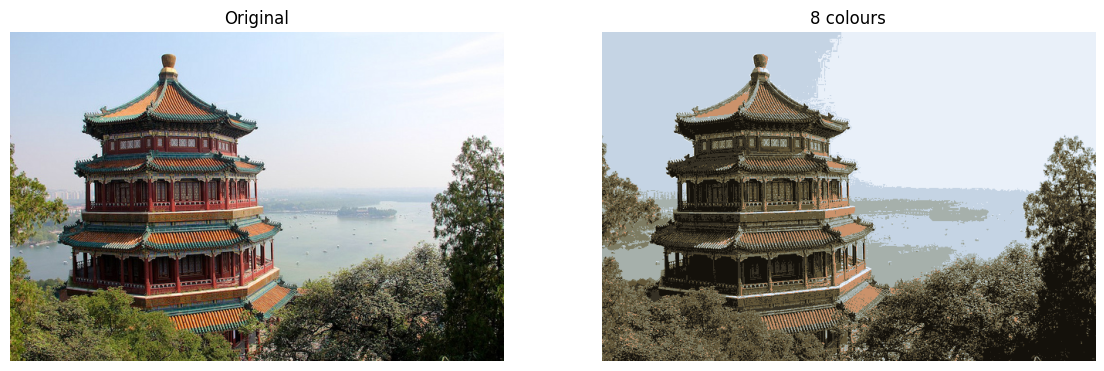

In [18]:
def reduce_colours(k):
    sample = pixels[np.random.default_rng(0).choice(len(pixels), 10000, replace=False)]
    model = KMeans(n_clusters=k, n_init=4, random_state=0).fit(sample)
    labels = model.predict(pixels)
    new_pixels = model.cluster_centers_[labels]          # swap each pixel for its centre colour
    return new_pixels.reshape(image.shape).astype("uint8")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[1].imshow(reduce_colours(8))
axes[1].set_title("8 colours")
for ax in axes:
    ax.axis("off")
plt.show()

With only 8 colours the picture is still easy to recognise. Notice that:

- the **sky** gets two of the eight colours, because it covers a large part of the picture, and k-means puts its
  centres where most of the pixels are
- the sky's smooth fade turns into a visible **edge** between two bands of colour
- the bright **red** of the pillars disappears, because it covers only a few pixels and gets merged with the browns
  and oranges

### Exercise 7

Use `reduce_colours` to make versions of the photo with **k = 2, 4 and 16** colours and show them side by side
(copy the plotting code above and change it to three panels).

What is the smallest k where you think the picture still looks acceptable? Each pixel normally needs 24 bits
(8 for each of red, green and blue). How many bits would each pixel need with 16 colours?

In [19]:
# Your code here

---
## 7. Summary

| | |
|---|---|
| **Clustering** | Grouping similar data points, with no labels or right answers |
| **K-means** | Repeats two steps: assign each point to its nearest centre, then move each centre to the mean of its points |
| **k** | You choose it. The elbow method can help |
| **Scaling** | Use `StandardScaler` when features are in different units, or the biggest numbers will dominate |
| **n_init** | Runs k-means from several starts and keeps the best, because one start can get stuck |
| **inertia_** | Total squared distance from points to their centres. Lower means tighter clusters |

### Limitations to remember

- K-means always returns exactly k clusters, even if the data has no real groups.
- It works best when the clusters are round blobs of similar size. Long, curved or very uneven clusters can confuse it.
- Every point must belong to a cluster, so unusual points (outliers) get forced into one and can pull its centre away.
- The cluster numbers mean nothing on their own. A person has to interpret the clusters.

### Exercise 8

Think of **two** real situations where k-means could be useful. For each one, say what a single data point would
be, which features you would use, and what you might do with the clusters once you have them.

In [20]:
# Your answer here (or use a markdown cell)